# Testing OSKAR and CASA Python Distributions

In [ ]:
import oskar # pyright: ignore[reportMissingImports]
import numpy as np
import matplotlib.pyplot as plt

print(dir(oskar))

['BDA', 'Binary', 'Imager', 'ImagingInterferometer', 'Interferometer', 'MeasurementSet', 'SettingsTree', 'Sky', 'Telescope', 'VisBlock', 'VisHeader', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_apps_lib', '_bda_utils', '_binary_lib', '_imager_lib', '_interferometer_lib', '_measurement_set_lib', '_settings_lib', '_sky_lib', '_telescope_lib', '_utils', '_version', '_vis_block_lib', '_vis_header_lib', 'absolute_import', 'apply_gains', 'barrier', 'bda', 'binary', 'imager', 'imaging_interferometer', 'interferometer', 'measurement_set', 'oskar_version_string', 'settings_tree', 'sky', 'telescope', 'utils', 'vis_block', 'vis_header', 'vis_list_to_matrix']


In [2]:
params = {
    "simulator": {
        "use_gpus": False
    },
    "observation" : {
        "num_channels": 1,
        "start_frequency_hz": 177.408e6,
        "frequency_inc_hz": 20e6,
        "phase_centre_ra_deg": 0.0,
        "phase_centre_dec_deg": -27.0,
        "num_time_steps": 8,
        "start_time_utc": "2025-03-03 05:30:00.00",
        "length": "00:02:00.000"
    },
    "telescope": {
        "input_directory": "../oskar_run_stage/telescope_model_AAstar"
    },
    "interferometer": {
        "oskar_vis_filename": "output/vis.vis",
        "ms_filename": "output/sim.ms",
        "channel_bandwidth_hz": 1e6,
        "time_average_sec": 8
    },
    "sky": {
        "oskar_sky_model/file": "./regrid/osm_output/gaussian_zenith_osm/no.1_177.408MHz.osm"
    }
}

settings = oskar.SettingsTree("oskar_sim_interferometer")
settings.from_dict(params)
settings["simulator/double_precision"] = True

In [6]:
ini_settings = oskar.SettingsTree("oskar_sim_interferometer", "test_intif_inis/test_intif_gen_bash.ini")
#ini_settings["observation/start_frequency_hz"] = 177.408e6
#ini_settings["telescope/input_directory"] = "../oskar_run_stage/telescope_model_AAstar"
#ini_settings["sky/oskar_sky_model/file"] = "./regrid/osm_output/gaussian_zenith_osm/no.1_177.408MHz.osm"

print(settings.to_dict())

#img_settings = oskar.SettingsTree("oskar_imager", "test_intif_inis/test_img_gen_bash.ini")

{'simulator/use_gpus': 'false', 'sky/oskar_sky_model/file': './regrid/osm_output/gaussian_zenith_osm/no.1_177.408MHz.osm', 'observation/phase_centre_dec_deg': '-27.0', 'observation/start_frequency_hz': '177408000.0', 'observation/frequency_inc_hz': '20000000.0', 'observation/start_time_utc': '2025-03-03 05:30:00.0', 'observation/length': '00:02:00.0', 'observation/num_time_steps': '8', 'telescope/input_directory': '../oskar_run_stage/telescope_model_AAstar', 'interferometer/channel_bandwidth_hz': '1000000.0', 'interferometer/time_average_sec': '8.0', 'interferometer/oskar_vis_filename': 'output/vis.vis', 'interferometer/ms_filename': 'output/sim.ms'}


In [11]:
data = np.array([000.000000,-27.000000,3.0000e-03,0.0,0.0,0.0,208.512e6,0.0,0.0,500.00,500.00])
sky_model = oskar.Sky.from_array(data)

sim = oskar.Interferometer(settings=ini_settings)
sim.set_sky_model(sky_model)
sim.run()

In [16]:
imager = oskar.Imager("double")
imager.set(fov_deg=1, image_size=512)
imager.set(input_file="output/sim.ms", output_root="output/test_point")
output = imager.run(return_images=1)
image = output["images"][0]

W|                                                                   
W|== WARNING: Skipped 6712 visibility points.
W|                                                                   
W|                                                                   
W|== WARNING: Skipped 6712 visibility points.
W|                                                                   
W|                                                                   
W|== WARNING: Skipped 6712 visibility points.
W|                                                                   
W|                                                                   
W|== WARNING: Skipped 6712 visibility points.
W|                                                                   
W|                                                                   
W|== WARNING: Skipped 6712 visibility points.
W|                                                                   
W|                                                                   


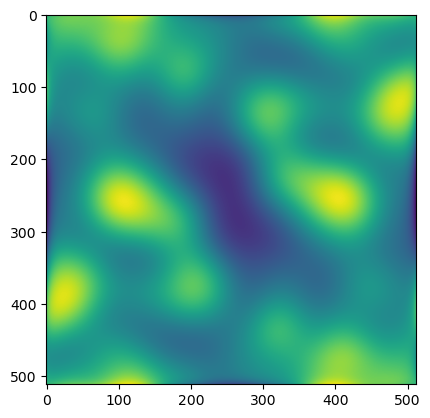

In [17]:
plt.imshow(image)
plt.show()

In [2]:
DEFAULT_INTERFEROMETER_SETTINGS = {
        "general": {
            "app": "oskar_sim_interferometer"
        },
        "simulator": {
            "use_gpus": False
        },
        "observation" : {
            "num_time_steps": 24,
            "start_time_utc": "2025-03-03 05:30:00.00",
            "length": "04:00:00.000"
        },
        "telescope": {
            "input_directory": "telescope_model",
            "apeture_array": {
                "element_pattern": {
                    "enable_numerical": "false"
                },
                "array_pattern": {
                    "element": {
                        "x_gain": 1.0,
                        "y_gain": 1.0,
                        "x_gain_error_time": 0.0015057,
                        "y_gain_error_time": 0.0015057,
                        "x_phase_error_fixed_deg": 0.0,
                        "y_phase_error_fixed_deg": 0.0,
                        "x_phase_error_time_deg": 0.0015057,
                        "y_phase_error_time_deg": 0.0015057
                    }
                }
            }
        },
        "interferometer": {
            "oskar_vis_filename": "oskar_output/vis.vis",
            "ms_filename": "oskar_output/sim.ms",
            "channel_bandwidth_hz": 1e6,
            "time_average_sec": 10.0,
            "uv_filter_max": 1000,
            "uv_filter_units": "Wavelengths"
        },
        "sky": {}
    }

DEFAULT_IMAGER_SETTINGS = {
        "general": {
            "app": "oskar_imager"
        },
        "image": {
            "use_gpus": False,
            "channel_snapshots": "false",
            "input_vis_data": "output/sim.ms",
            "root_path": "output/sim_image"
        }
    }

DEFAULT_GENERAL_SETTINGS = DEFAULT_IMAGER_SETTINGS | DEFAULT_INTERFEROMETER_SETTINGS | { "general": {} }

In [5]:
import json

print(json.dumps(DEFAULT_GENERAL_SETTINGS, indent = 4, sort_keys= True))

{
    "general": {},
    "image": {
        "channel_snapshots": "false",
        "input_vis_data": "output/sim.ms",
        "root_path": "output/sim_image",
        "use_gpus": false
    },
    "interferometer": {
        "channel_bandwidth_hz": 1000000.0,
        "ms_filename": "oskar_output/sim.ms",
        "oskar_vis_filename": "oskar_output/vis.vis",
        "time_average_sec": 10.0,
        "uv_filter_max": 1000,
        "uv_filter_units": "Wavelengths"
    },
    "observation": {
        "length": "04:00:00.000",
        "num_time_steps": 24,
        "start_time_utc": "2025-03-03 05:30:00.00"
    },
    "simulator": {
        "use_gpus": false
    },
    "sky": {},
    "telescope": {
        "apeture_array": {
            "array_pattern": {
                "element": {
                    "x_gain": 1.0,
                    "x_gain_error_time": 0.0015057,
                    "x_phase_error_fixed_deg": 0.0,
                    "x_phase_error_time_deg": 0.0015057,
                 

In [51]:
from astropy.coordinates import SkyCoord
from astropy.time import Time, TimeDelta
import astropy.units as u
import numpy as np

ZENITH_530  = SkyCoord(ra=0*u.deg, dec=-27*u.deg, frame='icrs') # SKA-Low Zenith at 5:30 am 2025-03-03

phase_ref_point = ZENITH_530

rt    = Time(val="2025-03-03T05:30:00.00", format='isot', scale='utc')

td = TimeDelta(4 * u.hr)

print((rt - td / 2).utc.value)

2025-03-03T03:30:00.000


In [19]:
from astropy.coordinates import EarthLocation
import re

locs = EarthLocation.get_site_names()

pattern = "|".join(["SKA", "Square", "Kilometer", "Array"])

flocs = [l for l in locs if re.search(pattern, l)]

print(flocs)

['ASKAP', 'Allen Telescope Array', 'Atacama Large Millimeter Array', 'Australia Telescope Compact Array', 'Australian Square Kilometre Array Pathfinder', 'Jansky Very Large Array', 'Long Wavelength Array 1', 'Low-Frequency Array', 'Murchison Widefield Array', 'SKA Low', 'SKA Mid', 'SKA-LOW', 'SKA-Low', 'SKA-MID', 'SKA-Mid', 'Sub-millimeter Array', 'Very Large Array']


In [28]:
ska_low_loc = EarthLocation.of_site('SKA-LOW')
print(ska_low_loc.lat.deg, ska_low_loc.lon.deg)

-26.824722079999994 116.76444820000002


In [ ]:

ska_low_loc.geocentric

(<Quantity -2565044.42978869 m>,
 <Quantity 5085763.69674313 m>,
 <Quantity -2861062.43955626 m>)

In [55]:
import astropy.units as u
import astropy.constants as c
import numpy as np

from astropy.cosmology import FlatLambdaCDM as fmodel
from astropy.cosmology import z_at_value as getz

cosmo = fmodel(H0=100 * u.km / u.s / u.Mpc, Om0=0.31, Ob0=0.048)

print(getz(cosmo.comoving_distance, 1000*u.Mpc).value)

0.36597455196291895
